# Logistic Regression: Binary Classification

## Logistic Regression

## What is Logistic Regression?

**Logistic Regression** is a Machine Learning algorithm used for **classification**.

It is mainly used for **binary classification**, where there are two classes.

Example:

- `0` → No car
- `1` → Owns car

Logistic Regression predicts the **probability** of each class and then uses a **threshold** to make the final prediction.

---

## Sigmoid Function

The **Sigmoid function** converts the model's output into a value between **0 and 1**.

This value can be treated as a **probability**.

### Formula

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Where:

- `z` = output from the model
- `e` = Euler's number ≈ `2.71828`

### Simple Example

Suppose the model gives:

$$
z = 2
$$

After applying the Sigmoid function:

$$
\sigma(2) \approx 0.88
$$

So:

**Probability = 88%**

---

## Why do we use Sigmoid?

The model's raw output can be any number, such as:

`-5, -2, 0, 2, 5`

The Sigmoid function converts these values into probabilities between `0` and `1`.

**Raw output → Sigmoid → Probability**

Example:

`2 → Sigmoid → 0.88 → 88%`

---

## model.predict_proba()

`model.predict_proba()` gives the **probability of each class**.

Example:

`model.predict_proba(X_test)`

Suppose the output is:

`[[0.30, 0.70]]`

This means:

- **Class 0 → 30%**
- **Class 1 → 70%**

The probabilities add up to **100%**.

## Threshold

### Code

    # Get probability of class 1
    probability = model.predict_proba(x_test)[:, 1]

    # Set threshold
    threshold = 0.5

    # Convert probability into 0 or 1
    y_pred = (probability >= threshold).astype(int)

    print(y_pred)

### Example

Suppose:

    probability = [0.30, 0.70, 0.45, 0.80]

With **threshold = 0.5**:

    0.30 < 0.5  → 0
    0.70 ≥ 0.5  → 1
    0.45 < 0.5  → 0
    0.80 ≥ 0.5  → 1

### Result

    [0, 1, 0, 1]

### How it works

    Probability
         ↓
    Compare with threshold
         ↓
    Probability ≥ 0.5 → 1
    Probability < 0.5 → 0

### Important

`.astype(int)` converts:

    True  → 1
    False → 0

It does **not** convert `0.70` directly to `0`.

---

## Understanding predict_proba()

**Probability**

↓

**Class 0        Class 1**

**30%              70%**

↓                     ↓

**No car        Owns car**

Since Class 1 has the higher probability:

**Prediction = 1**

---

## Threshold

A **threshold** is the value used to decide the final class.

The default threshold is usually:

**0.5**

### Example 1

Class 1 probability = **70%**

Since:

$$
0.70 > 0.50
$$

Prediction:

**Class 1**

---

### Example 2

Class 1 probability = **30%**

Since:

$$
0.30 < 0.50
$$

Prediction:

**Class 0**

---

## Simple Rule

**Probability ≥ 0.5 → Class 1**

**Probability < 0.5 → Class 0**

---

## Complete Example

Suppose we want to predict whether a person owns a car.

**Class 0 → No car**

**Class 1 → Owns car**

The model gives:

**Class 0 → 30%**

**Class 1 → 70% ← higher**

↓

**Prediction = 1**

### Probability

| Class 0 | Class 1 |
|----------|----------|
| 30% | 70% |
| No car | Owns car |

Therefore:

**Final Prediction = Class 1**

**Meaning = Person owns a car**

---

## Easy Way to Remember

**Logistic Regression** → Used for classification.

**Sigmoid** → Converts model output into probability between `0` and `1`.

**predict_proba()** → Shows probability for each class.

**Threshold** → Decides the final class.

**Default threshold = 0.5**

### In one line

**Logistic Regression → Sigmoid → Probability → Threshold → Final Prediction**

In [13]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\car_ownership.csv")
df.head()

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1
3,52000,0
4,46000,1


In [14]:
from sklearn.model_selection import train_test_split

x=df[["monthly_salary"]]
y=df["owns_car"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [15]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_test.to_list()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

In [17]:
model.predict(x_test)

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [18]:
model.score(x_test,y_test)

0.8888888888888888

In [19]:
8/9

0.8888888888888888

In [20]:
model.predict_proba(x_test)

array([[0.04530932, 0.95469068],
       [0.80955349, 0.19044651],
       [0.05158003, 0.94841997],
       [0.86480041, 0.13519959],
       [0.91687254, 0.08312746],
       [0.82967465, 0.17032535],
       [0.87995016, 0.12004984],
       [0.07564619, 0.92435381],
       [0.84806892, 0.15193108]])

# Model Evaluation: Accuracy, Precision and Recall

In [21]:
y_test.to_list()

[1, 0, 1, 0, 0, 0, 1, 1, 0]

In [22]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

## f1_score
### F1 Score Formula

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

### Precision Formula

$$
Precision = \frac{TP}{TP + FP}
$$

Where:

- **TP** = True Positive
- **FP** = False Positive

### Recall Formula

$$
Recall = \frac{TP}{TP + FN}
$$

Where:

- **TP** = True Positive
- **FN** = False Negative

---
### TP, TN, FP, FN

**1 = Positive**  
**0 = Negative**

| Actual | Predicted | Result |
|--------|-----------|--------|
| 1 | 1 | TP |
| 0 | 0 | TN |
| 0 | 1 | FP |
| 1 | 0 | FN |

In [23]:
print(y_test.to_list())
print(y_pred.tolist())

model.score(x_test,y_test)

[1, 0, 1, 0, 0, 0, 1, 1, 0]
[1, 0, 1, 0, 0, 0, 0, 1, 0]


0.8888888888888888

In [24]:
from sklearn.metrics import classification_report

report=classification_report(y_test,model.predict(x_test))
print(report)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



In [25]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(precision)

1.0


# Model Evaluation: F1 Score, Confusion Matrix

## F1 Score Formula

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

In [66]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,model.predict(x_test))
print(round(f1,2))

0.55


## conusion matrix

A **Confusion Matrix** is used to check how well a classification model is predicting the classes.

### Our Confusion Matrix

| True \ Predicted | No Car (0) | Owns Car (1) |
|---|---:|---:|
| **No Car (0)** | **5** | **0** |
| **Owns Car (1)** | **1** | **3** |

### How to Read It

- **Rows = True Labels** → What actually happened
- **Columns = Predicted Labels** → What the model predicted

### 1. True Negative (TN) = 5

Actual: **No Car**  
Predicted: **No Car**

✅ The model correctly predicted 5 people who do not own a car.

### 2. False Positive (FP) = 0

Actual: **No Car**  
Predicted: **Owns Car**

There are **0** such cases.

### 3. False Negative (FN) = 1

Actual: **Owns Car**  
Predicted: **No Car**

❌ The model incorrectly predicted 1 car owner as someone who does not own a car.

### 4. True Positive (TP) = 3

Actual: **Owns Car**  
Predicted: **Owns Car**

✅ The model correctly predicted 3 car owners.

### Summary

- **TN = 5**
- **FP = 0**
- **FN = 1**
- **TP = 3**

### Accuracy

Correct predictions:

$$
5 + 3 = 8
$$

Total predictions:

$$
5 + 0 + 1 + 3 = 9
$$

Therefore:

$$
Accuracy = \frac{8}{9} = 88.89\%
$$

So, the model correctly classified **8 out of 9** people.

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,model.predict(x_test))
cm

array([[431, 112],
       [ 11,  76]])

# heatmap

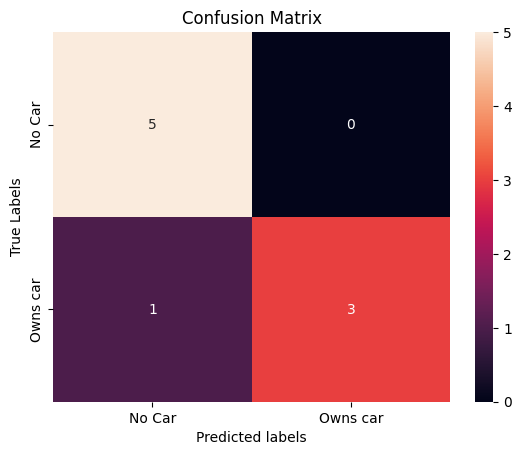

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
classes=["No Car","Owns car"]
sns.heatmap(cm,annot=True,xticklabels=classes,yticklabels=classes)

plt.xlabel("Predicted labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Logistic Regression: Multiclass Classification

<img width=300 height=300 src="..\Datasets\iris.png" />

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

iris=load_iris(as_frame=True)
df=iris.frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
df.target.unique()

array([0, 1, 2])

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

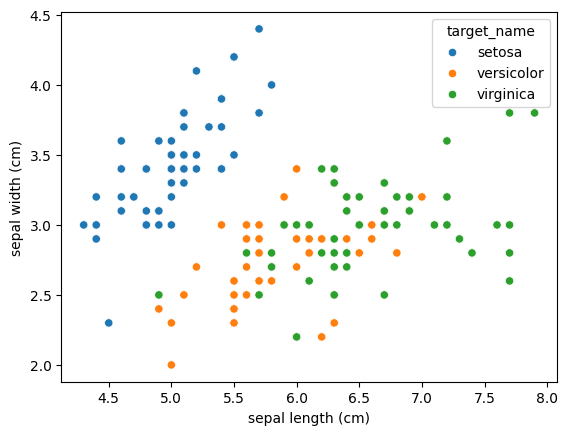

In [26]:
sns.scatterplot(df,x='sepal length (cm)',y='sepal width (cm)',hue='target_name')

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

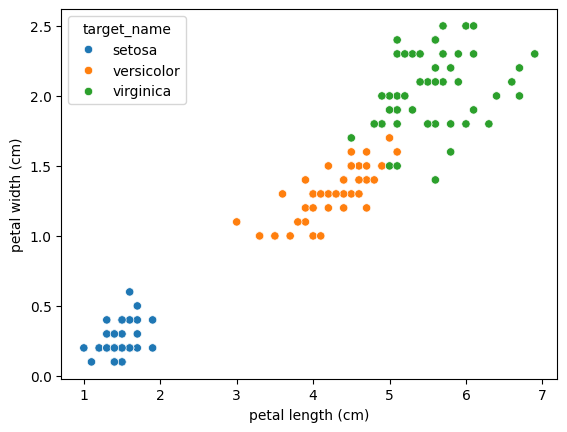

In [10]:
sns.scatterplot(df, x="petal length (cm)", y="petal width (cm)", hue="target_name")

In [11]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'target_name'],
      dtype='str')

In [12]:
x=df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)']]
y=df['target']

In [13]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=1)

## <h3>max_iter=100</h3>

`max_iter=100` means the model can **try up to 100 times** to find the best solution.
 
 Try → Improve → Try again → Improve → ... → Maximum 100 tries

```python
model = LogisticRegression(max_iter=100)

In [14]:
# LogisticRegression(
#     max_iter=300,          # Give learning up to 300 iterations
#     C=0.5,                 # More regularization than C=1
#     tol=0.001,             # Stop when improvement is sufficiently small
#     class_weight='balanced' # Give minority classes more importance
# )

In [15]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=200)
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
model.score(x_test,y_test)

0.9777777777777777

In [17]:
y_pred= model.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 0, 2, 2,
       1])

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
accuracy_score(y_test,y_pred)

0.9777777777777777

In [20]:
y_test[20:30].to_list()

[1, 1, 1, 0, 2, 1, 0, 0, 1, 2]

In [21]:
y_pred[20:30].tolist()

[1, 1, 2, 0, 2, 1, 0, 0, 1, 2]

In [22]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        18
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [23]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
cm

array([[14,  0,  0],
       [ 0, 17,  1],
       [ 0,  0, 13]])

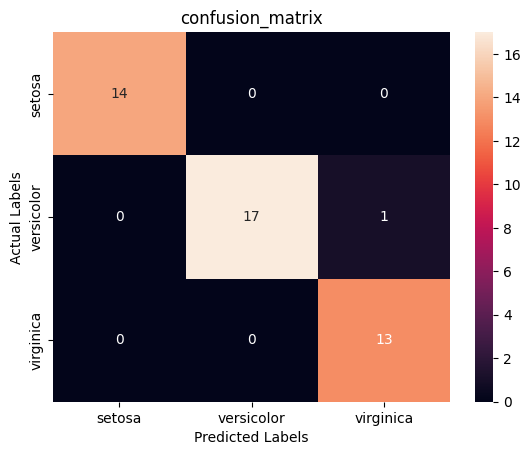

In [24]:
sns.heatmap(cm,xticklabels=iris.target_names,yticklabels=iris.target_names,annot=True)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("confusion_matrix")
plt.show()

# Support Vector Machine (SVM)


## 1. SVM — Support Vector Machine

SVM is a **supervised learning algorithm** used mainly for classification.

It tries to find the **best boundary (hyperplane)** that separates different classes.

**Example:**

🍎 🍎 🍎     |     🍊 🍊 🍊  
               ↑  
     Decision boundary

SVM finds a boundary that separates the classes **as well as possible**.

---

## 2. Margin

**Margin = distance between the decision boundary and the nearest data points.**

SVM tries to make this margin **as large as possible**.

**Example:**

🍎 🍎     ● | ●     🍊 🍊  
             ↑  
     Decision boundary

**● = Support Vectors**

👉 **Large margin = better separation**

---

## 3. Support Vectors

The data points **closest to the decision boundary** are called **Support Vectors**.

**Example:**

🍎 🍎   ● | ●   🍊 🍊  
         ↑   ↑  
    Support Vectors

They are important because they help determine the position of the decision boundary.

---

## 4. Kernel

A **kernel** helps SVM handle data that **cannot be separated by a straight line**.

A kernel transforms the data into a different feature space where separation may become possible.

**Common kernels:**

- **Linear**
- **Polynomial (poly)**
- **RBF**
- **Sigmoid**

---

## 5. Linear Kernel

**Linear kernel = used when a straight decision boundary is enough.**

**Example:**

🍎 🍎 🍎  
🍎 🍎  
----------------  ← Decision boundary  
🍊 🍊  
🍊 🍊 🍊

**Python:**

`SVC(kernel="linear")`

---

## 🧠 Easy to Remember

**SVM**  
↓  
Find a boundary  
↓  
Make the margin maximum  
↓  
Nearest points = Support Vectors  
↓  
Straight boundary → Linear Kernel  
↓  
Complex/non-linear boundary → Other Kernels

---

## One-line Definitions

- **SVM** → Finds the best boundary to separate classes.
- **Margin** → Distance between the boundary and nearest points.
- **Support Vector** → Data point closest to the boundary.
- **Kernel** → Helps SVM handle non-linear data.
- **Linear Kernel** → Creates a straight decision boundary.

<img width=400 height=400 src="..\Datasets\svm.jpg" />

## Common SVM Kernels

Think of a **kernel** as a way for SVM to choose **what kind of boundary it should use**.

---

## 1. Linear Kernel → Straight Line

Use when the classes can be separated with a **straight line**.

**Example:**

🍎 🍎 🍎  
🍎 🍎  
----------------  ← Straight boundary  
🍊 🍊  
🍊 🍊 🍊  

**Simple idea:**

👉 "A straight line is enough."

**Python:**

`SVC(kernel="linear")`

---

## 2. Polynomial Kernel → Curved Boundary

It can create a **curved boundary** using polynomial relationships.

**Example:**

🍎 🍎  
  🍎  
    )       ← Curved boundary  
  🍊  
🍊 🍊  

**Simple idea:**

👉 "The data has a polynomial/curved pattern."

**Python:**

`SVC(kernel="poly")`

---

## 3. RBF Kernel → Flexible Curved Boundary

**RBF = Radial Basis Function**

It is useful when the data has a **complex, non-linear pattern**.

**Example:**

🍎 🍎  
🍎 🍎 🍎  
🍎  

      ⭕     ← Flexible boundary

🍊 🍊  
🍊 🍊 🍊  

**Simple idea:**

👉 "The data is complicated, so I need a flexible boundary."

RBF is often a **good default choice for non-linear data**.

**Python:**

`SVC(kernel="rbf")`

---

## 4. Sigmoid Kernel → S-shaped Behavior

The sigmoid kernel is based on the **sigmoid function** and can create a non-linear decision boundary.

**Simple idea:**

👉 "Use a sigmoid-based mathematical transformation."

**Python:**

`SVC(kernel="sigmoid")`

---

## 🧠 Easy Way to Remember

| Kernel | Simple Meaning | Boundary |
|---|---|---|
| **Linear** | Simple separation | Straight |
| **Polynomial** | Polynomial relationship | Curved |
| **RBF** | Complex/non-linear data | Flexible curve |
| **Sigmoid** | Sigmoid-based transformation | Non-linear |

### Quick Memory Trick

**Linear → Straight**

**Polynomial → Curved**

**RBF → Flexible/Complex**

**Sigmoid → S-shaped**

In [25]:
import pandas as pd
df = pd.read_excel(r"..\Datasets\Raisin_Dataset.xlsx")
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [26]:
from sklearn.model_selection import train_test_split

x=df.drop("Class",axis=1)
y=df["Class"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)


In [27]:
# model training using rbf
from sklearn.svm import SVC
model=SVC(kernel="rbf")
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

model.n_iter_


              precision    recall  f1-score   support

       Besni       0.86      0.81      0.83        95
     Kecimen       0.80      0.85      0.82        85

    accuracy                           0.83       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.83      0.83      0.83       180



array([242], dtype=int32)

In [29]:
# model training using linear kernal
from sklearn.svm import SVC
model=SVC(kernel="linear")
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

model.n_iter_

              precision    recall  f1-score   support

       Besni       0.89      0.89      0.89        95
     Kecimen       0.88      0.87      0.88        85

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



array([51923213], dtype=int32)

## `model.n_iter_`

`model.n_iter_` tells you **how many iterations the model actually took to converge during training**.

### Simple Example

`model = LogisticRegression(max_iter=300)`

`model.fit(X_train, y_train)`

`print(model.n_iter_)`

**Output:**

`[12]`

This means:

> The model needed **12 iterations** to finish training/converge.

---

### `max_iter` vs `n_iter_`

| Parameter | Meaning |
|---|---|
| `max_iter=300` | Maximum number of iterations the model is allowed to use |
| `model.n_iter_` | Actual number of iterations the model used |

### Example

`LogisticRegression(max_iter=300)`

If:

`model.n_iter_ = [12]`

Then:

- **Maximum allowed:** 300 iterations
- **Actually used:** 12 iterations

So, `n_iter_` helps you check **how many iterations the model needed to converge**.

# Data Pre-processing: Scaling

## Feature Scaling

Feature scaling brings numerical features to a similar scale.

Two common methods are:

1. **StandardScaler**
2. **MinMaxScaler**

---

## 1. StandardScaler

StandardScaler transforms the data so that:

- Mean is approximately `0`
- Standard deviation is approximately `1`

### Formula

$$
z = \frac{x - \mu}{\sigma}
$$

Where:

- `x` = original value
- `μ` = mean
- `σ` = standard deviation
- `z` = scaled value

### Example

Suppose:

- Mean = `50`
- Standard deviation = `10`
- Value = `70`

Then:

$$
z = \frac{70 - 50}{10}
$$

$$
z = 2
$$

So:

**70 → 2**

This means `70` is **2 standard deviations above the mean**.

### Python Code

    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

**Important:**

Use `fit_transform()` on training data.

Use only `transform()` on test data.

---

## 2. MinMaxScaler

MinMaxScaler usually converts values into a range between **0 and 1**.

### Formula

$$
x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

Where:

- `x` = original value
- `xmin` = minimum value
- `xmax` = maximum value

### Example

Suppose:

- Minimum = `10`
- Maximum = `50`
- Value = `30`

Then:

$$
x_{scaled} = \frac{30 - 10}{50 - 10}
$$

$$
x_{scaled} = \frac{20}{40}
$$

$$
x_{scaled} = 0.5
$$

So:

**30 → 0.5**

### Python Code

    from sklearn.preprocessing import MinMaxScaler

    scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

---

## StandardScaler vs MinMaxScaler

| StandardScaler | MinMaxScaler |
|---|---|
| Uses mean and standard deviation | Uses minimum and maximum |
| Mean becomes approximately `0` | Values usually become `0` to `1` |
| Formula: `(x - mean) / std` | Formula: `(x - min) / (max - min)` |
| Can produce negative values | Usually produces values between `0` and `1` |

---

## Easy Way to Remember

**StandardScaler:**

> How far is the value from the mean?

**MinMaxScaler:**

> Where does the value lie between the minimum and maximum?

### Simple Example

Original data:

`[10, 20, 30, 40, 50]`

MinMaxScaler:

`[0, 0.25, 0.5, 0.75, 1]`

StandardScaler:

Values are transformed so that the feature is centered around **0** with a standard deviation of approximately **1**.

In [ ]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
x_train.head(1)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
666,178692,594.722171,384.038046,0.763554,181288,0.747046,1622.032


In [ ]:
x_train_scaled[0,:]

array([ 2.38317597,  1.44547801,  2.65442512, -0.20037568,  2.25609195,
        0.88762218,  1.70608967])

In [ ]:
# with standardscaling
from sklearn.svm import SVC
model=SVC(kernel="linear")
model.fit(x_train_scaled,y_train)

y_pred = model.predict(x_test_scaled)

from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print(report)

model.n_iter_

              precision    recall  f1-score   support

       Besni       0.91      0.87      0.89        95
     Kecimen       0.87      0.91      0.89        85

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



array([2351], dtype=int32)

# Sklearn Pipeline

In [71]:
from sklearn.pipeline import Pipeline

pipeline=Pipeline([
    ("scale",StandardScaler()),
    ("svc",SVC(kernel="linear"))
])

In [72]:
pipeline.fit(x_train,y_train)

y_pred=pipeline.predict(x_test)

from sklearn.metrics import classification_report

report=classification_report(y_test,y_pred)

print(report)

              precision    recall  f1-score   support

       Besni       0.91      0.87      0.89        95
     Kecimen       0.87      0.91      0.89        85

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



In [73]:
pipeline.fit(x_train, y_train).score(x_test, y_test)

0.8888888888888888

In [76]:
pipeline.set_params(svc__C=20).fit(x_train, y_train).score(x_test, y_test)

0.8944444444444445

## Pipeline in Machine Learning

A **Pipeline** connects multiple ML steps together and runs them **in order**.

For example:

**Data → StandardScaler → SVC → Prediction**

This means the data is first scaled and then given to the SVC model.

---

## Example

Suppose we want to use:

- `StandardScaler` → Scale the features
- `SVC` → Classification model

The Pipeline is:

    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.svm import SVC

    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="linear"))
    ])

---

## Understanding the Pipeline

    ("scale", StandardScaler())

`scale` is the **name of the step**.

`StandardScaler()` performs feature scaling.

---

    ("svc", SVC(kernel="linear"))

`svc` is the **name of the step**.

`SVC(kernel="linear")` is the SVM classification model.

So the Pipeline is:

**Input Data → StandardScaler → SVC**

---

## Training the Pipeline

    pipeline.fit(x_train, y_train)

The Pipeline automatically:

1. Fits the `StandardScaler` using `x_train`
2. Scales `x_train`
3. Trains the SVC model using the scaled data

You don't need to manually write:

    scaler.fit_transform(x_train)

---

## Making Predictions

    y_pred = pipeline.predict(x_test)

The Pipeline automatically:

1. Uses the already-fitted scaler
2. Scales `x_test`
3. Sends the scaled data to SVC
4. Makes predictions

So:

**x_test → StandardScaler → SVC → y_pred**

---

## `set_params()`

`set_params()` is used to **change the parameters of a model inside the Pipeline**.

Example:

    pipeline.set_params(svc__C=10)

Here:

**`svc`** → name of the Pipeline step

**`C`** → parameter of SVC

**`__`** → connects the step name and parameter name

So:

    svc__C

means:

**Change the `C` parameter of the `svc` step.**

Therefore:

    pipeline.set_params(svc__C=10)

changes the SVC to:

    SVC(C=10, kernel="linear")

---

## `.fit()` and `.score()`

You can write:

    pipeline.set_params(svc__C=10).fit(x_train, y_train).score(x_test, y_test)

This performs three operations:

### 1. `set_params()`

    pipeline.set_params(svc__C=10)

Changes the SVC `C` value to `10`.

### 2. `fit()`

    .fit(x_train, y_train)

Scales the training data and trains the SVC model.

### 3. `score()`

    .score(x_test, y_test)

Scales the test data, makes predictions, and calculates the model's score.

For a classification model like SVC, `.score()` returns **accuracy**.

---

## Complete Flow

    pipeline.set_params(svc__C=10)
                  ↓
          Change C to 10
                  ↓
    pipeline.fit(x_train, y_train)
                  ↓
       StandardScaler
                  ↓
             Train SVC
                  ↓
    pipeline.score(x_test, y_test)
                  ↓
       Scale test data
                  ↓
            Make predictions
                  ↓
              Accuracy

---

## Easy Way to Remember

> **Pipeline = Preprocessing + Model together**

Example:

**StandardScaler → SVC**

And:

> **`svc__C=10` = Change the `C` parameter of SVC inside the Pipeline.**

# Naive Bayes: Theory

## Naive Bayes

**Naive Bayes** is a **classification algorithm** based on **probability**.

It uses **Bayes' Theorem** to answer:

> "Given these features, which class is most likely?"

---

## 1. Bayes' Theorem

$$
P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}
$$

### Meaning

- **P(A|B)** → Probability of A happening, given B has happened
- **P(B|A)** → Probability of B happening, given A has happened
- **P(A)** → Probability of A
- **P(B)** → Probability of B

---

## 2. Simple Spam Email Example 📧

Suppose we have emails containing the words **"free"** and **"lottery"**.

We want to predict:

> **Is this email Spam?**

Suppose:

$$
P(Spam) = 30\%
$$

$$
P(Free|Spam) = 40\%
$$

$$
P(Lottery|Spam) = 60\%
$$

---

## 3. Naive Assumption

Naive Bayes makes an important assumption:

> **The features are independent of each other.**

So it assumes that `"free"` and `"lottery"` are independent:

$$
P(Free, Lottery|Spam)
=P(Free|Spam) \times P(Lottery|Spam)
$$

Therefore:

$$
= 0.4 \times 0.6
$$

$$
= 0.24
$$

So:

$$
P(Free, Lottery|Spam) = 24\%
$$

---

## 4. Why is it called "Naive"?

It is called **Naive Bayes** because of the **naive assumption** that the features are independent.

For example:

**Email**

- contains `"free"`
- contains `"lottery"`

Naive Bayes assumes:

> `"free"` and `"lottery"` are independent of each other.

Even though in real life, these words may be related.

---

## 5. How does Naive Bayes make a prediction?

Suppose a new email contains:

> **"You won a free lottery!"**

The model calculates:

$$
P(Spam|Free,Lottery)
$$

and

$$
P(Not\ Spam|Free,Lottery)
$$

Suppose the results are:

- **Spam → 72%**
- **Not Spam → 28%**

Since **Spam has the higher probability**, the model predicts:

### **Spam**

---

## 6. In Simple Words

Naive Bayes looks at the features and asks:

> **"Which class has the highest probability?"**

Example:

**Email contains `"free"` + `"lottery"`**

↓

**Naive Bayes**

↓

- Spam → **72%**
- Not Spam → **28%**

↓

**Prediction → Spam**

---

## 7. Common Uses

- 📧 Spam detection
- 📝 Text classification
- 😊 Sentiment analysis
- 📰 News/article classification

---

## Key Point 🧠

**Naive Bayes = Probability + Bayes' Theorem + Independence Assumption**

It is mainly used for **classification**.

# Naive Bayes: SMS Spam Classification

## Naive Bayes

### 1. Bernoulli Naive Bayes (`BernoulliNB`)
- Used for **binary features (0/1)**.
- Example: **Spam detection** — whether a word is present (`1`) or absent (`0`).

### 2. Multinomial Naive Bayes (`MultinomialNB`)
- Used for **count/frequency-based features**.
- Example: **Text classification** — `"free"` appears 3 times, `"money"` appears 2 times, etc.

### 3. Gaussian Naive Bayes (`GaussianNB`)
- Used for **continuous numerical features**.
- Assumes the features approximately follow a **normal (Gaussian) distribution**.
- Example: **Age = 25.5, Fare = 72.5** for predicting whether a passenger survived.

---

## Quick Memory Trick 🧠

**Bernoulli → Binary → 0 / 1**

**Multinomial → Counts → Word frequency**

**Gaussian → Continuous → Real numbers**

In [63]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [64]:
df["Category"]=df["Category"].replace("ham","Not Spam")

In [65]:
df.head()

,Category,Message
0,Not Spam,"Go until jurong point, crazy.. Available only ..."
1,Not Spam,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,Not Spam,U dun say so early hor... U c already then say...
4,Not Spam,"Nah I don't think he goes to usf, he lives aro..."


In [66]:
df["Category"].value_counts()

Category
Not Spam    4825
spam         747
Name: count, dtype: int64

In [67]:
df.groupby("Category").describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
Not Spam    4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
Not Spam   30  
spam        4

In [68]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.Message,df.Category ,test_size=0.2,random_state=1)

In [69]:
from sklearn.feature_extraction.text import CountVectorizer
v=CountVectorizer()

x_train_count=v.fit_transform(x_train)

In [70]:
# print(v.get_feature_names_out()[0:10])
# print(x_train_count.toarray()[0,0:10])

In [71]:
len(x_train_count.toarray()[1])

7711

In [72]:
x_test_count=v.transform(x_test)

In [74]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train_count,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [75]:
model.score(x_test_count,y_test)

0.989237668161435

In [76]:
from sklearn.metrics import classification_report
print(classification_report(y_test,model.predict(x_test_count)))

              precision    recall  f1-score   support

    Not Spam       0.99      1.00      0.99       968
        spam       0.98      0.94      0.96       147

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [117]:
i=[
    "press this link to win lottery",
   "Hi How are you"
   ]
i_count=v.transform(i)
print(model.predict(i_count))
model.predict_proba(i_count)

['spam' 'Not Spam']


array([[0.10047819, 0.89952181],
       [0.99890861, 0.00109139]])

In [115]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,model.predict(x_test_count))
cm

array([[965,   3],
       [  9, 138]])

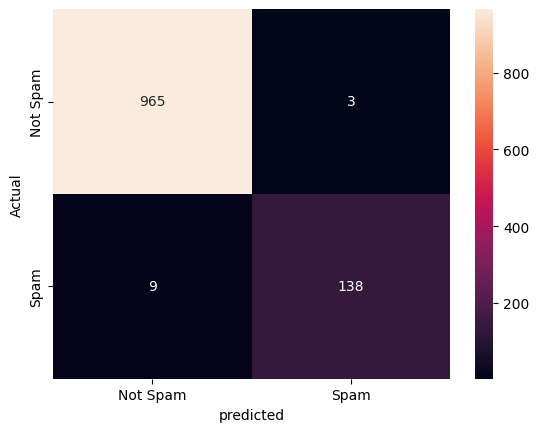

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
label=["Not Spam","Spam"]
sns.heatmap(cm,annot=True,xticklabels=label,yticklabels=label,fmt="d")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()


In [104]:
# training model using pipelines
from sklearn.pipeline import Pipeline

pipe=Pipeline([
    ("cv",CountVectorizer()),
    ("NB",MultinomialNB())
])

pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cv', ...), ('NB', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [105]:
pipe.score(x_test,y_test)

0.989237668161435

# Decision Tree: Theory

## Decision Tree 🌳

A **Decision Tree** is a **supervised machine learning algorithm** that makes decisions by asking a series of **questions**.

It looks like a tree:

    Weather?
    /      \
    Sunny   Rainy
      |       |
    Don't     Play
    Play

## Simple Example

Suppose we want to predict whether someone will **play cricket**:

| Weather | Play |
|---|---|
| Sunny | No |
| Sunny | No |
| Rainy | Yes |
| Rainy | Yes |
| Cloudy | Yes |

The Decision Tree asks:

    Is Weather Sunny?
          ↓
       Yes → No
       No  → Yes

The tree chooses questions that create the **purest groups**.

---

## Gini Impurity

**Gini Impurity** tells us how **mixed** the classes are in a group.

### Formula

$$
Gini = 1 - \sum p_i^2
$$

## Example 1: Pure Group

Suppose:

    10 people

    Yes → 10
    No  → 0

Then:

$$
Gini = 1 - (1^2 + 0^2)
$$

$$
Gini = 0
$$

**Gini = 0 → Completely pure ✅**

## Example 2: Mixed Group

Suppose:

    10 people

    Yes → 5
    No  → 5

Then:

$$
Gini = 1 - (0.5^2 + 0.5^2)
$$

$$
Gini = 1 - 0.5
$$

$$
Gini = 0.5
$$

**Gini = 0.5 → Very mixed**

### Remember

    Gini = 0     → Pure
    Higher Gini  → More mixed

---

## Entropy

**Entropy** measures the amount of **uncertainty or impurity** in the data.

### Formula

$$
Entropy = -\sum p_i \log_2(p_i)
$$

## Example 1: Pure Group

Suppose:

    Yes → 10
    No  → 0

Then:

$$
Entropy = 0
$$

There is **no uncertainty**.

## Example 2: 50/50 Group

Suppose:

    Yes → 5
    No  → 5

Then:

$$
Entropy = -(0.5\log_2(0.5) + 0.5\log_2(0.5))
$$

$$
Entropy = 1
$$

So:

    Entropy = 0 → Pure / No uncertainty
    Entropy = 1 → Maximum uncertainty (for 2 classes)

---

## Gini vs Entropy

| | Gini | Entropy |
|---|---|---|
| Measures | Impurity | Uncertainty |
| Best value | **0** | **0** |
| Scikit-learn | `criterion="gini"` | `criterion="entropy"` |

---

## In Scikit-learn

### Using Gini

    from sklearn.tree import DecisionTreeClassifier

    model = DecisionTreeClassifier(criterion="gini")

### Using Entropy

    model = DecisionTreeClassifier(criterion="entropy")

---

## 🧠 Easy Memory Trick

🌳 **Decision Tree** → Asks questions

**Gini / Entropy** → Helps choose the **best question**

**Gini = 0** → Pure

**Entropy = 0** → Pure

## gini Purity

**Purity** means how much the data in a group belongs to the **same class**.

- **High purity** → Classes are mostly the same.
- **Low purity** → Classes are mixed.

### Example

    Yes → 10
    No  → 0

    → 100% Pure ✅

    Yes → 5
    No  → 5

    → 50% Pure / Completely mixed ❌

### 🧠 Remember

**High Purity → Low Impurity**

**Low Purity → High Impurity**

Gini and Entropy measure **impurity**, which is the opposite of purity.

# Decision Tree: Salary Classification

In [1]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\salaries.csv")
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [2]:
df.shape

(16, 4)

In [3]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df["company"]=le.fit_transform(df["company"])
df["job"]=le.fit_transform(df["job"])
df["degree"]=le.fit_transform(df["degree"])
df.head()

,company,job,degree,salary_more_then_100k
0,2,2,0,0
1,2,2,1,0
2,2,0,0,1
3,2,0,1,1
4,2,1,0,0


In [4]:
df.rename(columns={"salary_more_then_100k":"Salary"},inplace=True)

In [5]:
df.head()

,company,job,degree,Salary
0,2,2,0,0
1,2,2,1,0
2,2,0,0,1
3,2,0,1,1
4,2,1,0,0


In [6]:
df.columns

Index(['company', 'job', 'degree', 'Salary'], dtype='str')

In [7]:
from sklearn.tree import DecisionTreeClassifier

x=df[['company', 'job', 'degree']]
y=df["Salary"]

model=DecisionTreeClassifier(criterion="gini")
model.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
# model = DecisionTreeClassifier(
#     criterion="entropy",       # How to choose split
#     max_depth=5,               # Maximum 5 levels
#     min_samples_split=10,      # Need ≥ 10 samples to split
#     min_samples_leaf=5         # Each leaf needs ≥ 5 samples
# )

In [8]:
from sklearn.metrics import classification_report
y_pred=model.predict(x)
print(classification_report(y,y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [11]:

model.predict([[2,2,0],[2,0,1]])

C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0, 1])

In [9]:
from sklearn.tree import export_text
print(export_text(model,feature_names=list(x.columns)))

|--- company <= 0.50
|   |--- degree <= 0.50
|   |   |--- class: 0
|   |--- degree >  0.50
|   |   |--- job <= 1.00
|   |   |   |--- class: 1
|   |   |--- job >  1.00
|   |   |   |--- class: 0
|--- company >  0.50
|   |--- company <= 1.50
|   |   |--- class: 1
|   |--- company >  1.50
|   |   |--- job <= 0.50
|   |   |   |--- class: 1
|   |   |--- job >  0.50
|   |   |   |--- degree <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- degree >  0.50
|   |   |   |   |--- job <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- job >  1.50
|   |   |   |   |   |--- class: 0



In [137]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

# Data
df = pd.DataFrame({
    "Weather": [0, 0, 1, 1, 2, 2],
    "Play":    [0, 0, 1, 1, 1, 0]
})

# Weather:
# 0 → Sunny
# 1 → Cloudy
# 2 → Rainy

# Play:
# 0 → No
# 1 → Yes

# Features and target
X = df[["Weather"]]
y = df["Play"]

# Train Decision Tree
model = DecisionTreeClassifier(criterion="gini", max_depth=2)
model.fit(X, y)

# Display the tree
print(export_text(model, feature_names=["Weather"]))

|--- Weather <= 0.50
|   |--- class: 0
|--- Weather >  0.50
|   |--- Weather <= 1.50
|   |   |--- class: 1
|   |--- Weather >  1.50
|   |   |--- class: 0



# Handle Class Imbalance: Theory

**Class imbalance** happens when one class has many more samples than another.

### Example

    Normal → 9900
    Fraud  → 100

Here:
- **Normal** = Majority class
- **Fraud** = Minority class

---

## 1. Under-sampling

Reduce the **majority class**.

    Before:
    Normal → 9900
    Fraud  → 100

    After:
    Normal → 100
    Fraud  → 100

**Problem:** Some useful majority data is removed.

---

## 2. Over-sampling by Duplication

Increase the **minority class** by duplicating existing samples.

    Before:
    Normal → 9900
    Fraud  → 100

    After:
    Normal → 9900
    Fraud  → 9900

**Problem:** Duplicating the same samples can cause **overfitting**.

---

## 3. SMOTE

**SMOTE = Synthetic Minority Over-sampling Technique**

SMOTE creates **new synthetic minority samples** using nearby minority samples.

    Original minority points:
    
    ●       ●
       ●

    SMOTE creates new points:

    ●   ●   ●
      ●   ●

**Advantage:** It creates new samples instead of simply copying existing ones.

---

## 4. SMOTE + Tomek Links

**Tomek Links** identify samples that are very close to the **boundary between two classes**.

They can be removed to make the classes **better separated**.

    Majority ● ● ●
                ●  ← boundary
                ○
             ○  ○  ○
             Minority

**Tomek Links → Remove problematic boundary points**

---

## 5. Ensemble Method

Use **multiple models** and combine their predictions.

    Model 1 → Fraud
    Model 2 → Fraud
    Model 3 → Normal

             ↓

        Majority Vote

             ↓

           Fraud

The final prediction is based on the **majority vote**.

---

## 🧠 Easy Memory Trick

    Under-sampling      → Remove majority samples
    Over-sampling       → Duplicate minority samples
    SMOTE               → Create new minority samples
    Tomek Links         → Remove boundary samples
    Ensemble            → Combine multiple models

### Important

**Class imbalance = One class has far more samples than another.**

Example:

    9900 Normal
     100 Fraud

A model could predict **Normal every time** and get **99% accuracy**, but it would be very poor at detecting Fraud.

Therefore, we use techniques to **handle class imbalance**.

## Handling Class Imbalance

## 1. Under Sampling

Reduces the majority class samples.

    from imblearn.under_sampling import RandomUnderSampler

    under = RandomUnderSampler(random_state=1)

    x_train_under, y_train_under = under.fit_resample(
        x_train, y_train
    )


## 2. Over Sampling by Duplication

Duplicates minority class samples.

    from imblearn.over_sampling import RandomOverSampler

    over = RandomOverSampler(random_state=1)

    x_train_over, y_train_over = over.fit_resample(
        x_train, y_train
    )


## 3. SMOTE

Creates new synthetic samples for the minority class.

    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=1)

    x_train_smote, y_train_smote = smote.fit_resample(
        x_train, y_train
    )


## 4. SMOTE + Tomek

SMOTE creates new minority samples, and Tomek removes overlapping samples.

    from imblearn.combine import SMOTETomek

    tomek = SMOTETomek(random_state=1)

    x_train_tomek, y_train_tomek = tomek.fit_resample(
        x_train, y_train
    )


## 5. Ensemble Method

Uses multiple balanced subsets and combines their predictions.

    from imblearn.ensemble import EasyEnsembleClassifier

    ensemble = EasyEnsembleClassifier(random_state=1)

    ensemble.fit(x_train, y_train)

    y_pred_ensemble = ensemble.predict(x_test)


## Summary

| Method | What it does |
|---|---|
| Under Sampling | Removes majority class samples |
| Over Sampling | Duplicates minority class samples |
| SMOTE | Creates synthetic minority samples |
| SMOTE + Tomek | Creates minority samples + removes overlapping samples |
| Ensemble | Uses multiple balanced subsets/models |

| Method | Main algorithm |
|---|---|
| `RandomUnderSampler` | Under-sampling |
| `RandomOverSampler` | Random over-sampling |
| `SMOTE` | Synthetic sampling |
| `SMOTETomek` | SMOTE + Tomek Links |
| `EasyEnsembleClassifier` | **Under-sampling + AdaBoost EasyEnsembleClassifier uses AdaBoost (Adaptive Boosting) internally, with decision trees as the base classifiers.** |

# Handle Class Imbalance Using imblearn: Churn Prediction

In [28]:
import pandas as pd
df=pd.read_csv(r"..\Datasets\churn.csv")
df.sample(5)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
605,11,0,37,0,3660,76,0,24,2,1,1,25,168.120,0
3059,12,0,40,2,4820,89,9,27,3,1,1,30,232.360,0
2726,14,0,36,0,3180,41,7,14,3,1,2,30,156.840,1
2826,12,0,37,0,3105,46,7,15,3,1,2,30,154.040,1
1546,11,0,13,1,9228,175,87,53,4,1,1,45,452.575,0


In [29]:
df.shape

(3150, 14)

In [30]:
df[df["Churn"]==1].shape

(495, 14)

In [31]:
churn_percentage_1 = (495 / 3150) * 100
print(churn_percentage_1)

15.714285714285714


In [32]:
df.Churn.value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

<Axes: xlabel='Churn'>

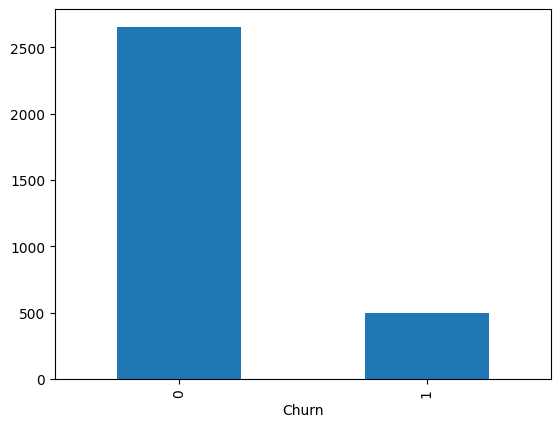

In [33]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

In [34]:
df.isna().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [35]:
x=df.drop("Churn",axis=1)
y=df["Churn"]

---

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

model=LogisticRegression(max_iter=2000)

model.fit(x_train,y_train)

print(classification_report(y_test,model.predict(x_test)))



              precision    recall  f1-score   support

           0       0.91      0.96      0.94       543
           1       0.64      0.44      0.52        87

    accuracy                           0.89       630
   macro avg       0.78      0.70      0.73       630
weighted avg       0.88      0.89      0.88       630



C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
y_train.value_counts()

Churn
0    2112
1     408
Name: count, dtype: int64

---

In [38]:
from imblearn.under_sampling import RandomUnderSampler

rus=RandomUnderSampler(random_state=1)

x_train_rus,y_train_rus=rus.fit_resample(x_train , y_train)
y_train_rus.value_counts()


Churn
0    408
1    408
Name: count, dtype: int64

In [39]:
model=LogisticRegression(max_iter=2000)

model.fit(x_train_rus,y_train_rus)

print(classification_report(y_test,model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89       543
           1       0.44      0.90      0.59        87

    accuracy                           0.83       630
   macro avg       0.71      0.86      0.74       630
weighted avg       0.91      0.83      0.85       630



C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---

In [40]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=1)

x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)
smote.fit(x_train_smote,y_train_smote)

y_train_smote.value_counts()

Churn
0    2112
1    2112
Name: count, dtype: int64

In [41]:
model=LogisticRegression(max_iter=2000)

model.fit(x_train_smote,y_train_smote)

print(classification_report(y_test,model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      0.79      0.88       543
           1       0.40      0.87      0.55        87

    accuracy                           0.80       630
   macro avg       0.69      0.83      0.71       630
weighted avg       0.90      0.80      0.83       630



C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---

In [ ]:
from imblearn.combine import SMOTETomek

tomek=SMOTETomek(random_state=1)

x_train_tomek,y_train_tomek=tomek.fit_resample(x_train,y_train)

tomek.fit(x_train_tomek,y_train_tomek)

,sampling_strategy,'auto'
,random_state,1
,smote,None
,tomek,None
,n_jobs,None


In [54]:
y_train_tomek.value_counts()

Churn
0    2084
1    2084
Name: count, dtype: int64

In [53]:
model=LogisticRegression(max_iter=2000)

model.fit(x_train_tomek,y_train_tomek)

print(classification_report(y_test,model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      0.79      0.87       543
           1       0.40      0.87      0.55        87

    accuracy                           0.80       630
   macro avg       0.69      0.83      0.71       630
weighted avg       0.90      0.80      0.83       630



C:\Users\thiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [57]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,model.predict(x_test))
cm

array([[430, 113],
       [ 11,  76]])

<Axes: >

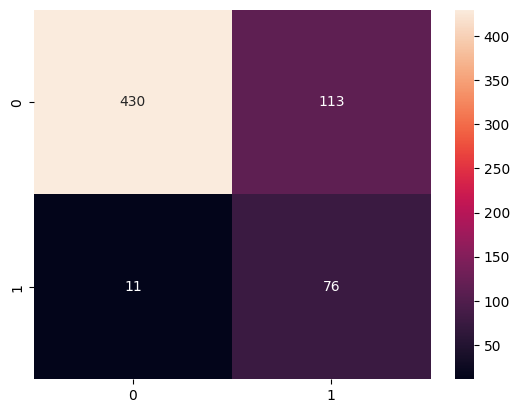

In [60]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt="d")

---

In [62]:
from imblearn.ensemble import EasyEnsembleClassifier

ensemble = EasyEnsembleClassifier(random_state=1)

ensemble.fit(x_train, y_train)

y_pred_ensemble = ensemble.predict(x_test)
print(classification_report(y_test,y_pred_ensemble))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91       543
           1       0.48      0.94      0.64        87

    accuracy                           0.85       630
   macro avg       0.74      0.89      0.77       630
weighted avg       0.92      0.85      0.87       630



<Axes: >

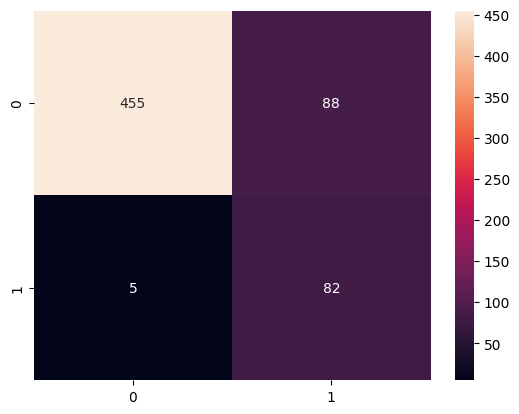

In [63]:
cm=confusion_matrix(y_test,y_pred_ensemble)
sns.heatmap(cm,annot=True,fmt="d")